In [1]:
import os
import random
import numpy as np
import torch
from IPython.display import display
import clip
from PIL import Image
from tqdm import tqdm
import pandas as pd
from PIL import Image

In [2]:
device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f"Using device: {device}")
batch_size = 64

Using device: mps


In [3]:
def make_path(images_dir, image_id):
    return os.path.normpath(os.path.join(images_dir, image_id + ".jpg"))

def load_model(model_name, device):
    model, preprocess = clip.load(model_name, device=device)
    model.eval()
    return model, preprocess

def encode_images(image_paths, model, preprocess, batch_size, device):
    embeddings = []

    with torch.no_grad():
        for i in tqdm(range(0, len(image_paths), batch_size), desc="Encoding Images"):
            batch_paths = image_paths[i:i + batch_size]

            images = torch.stack([
                preprocess(Image.open(p).convert("RGB"))
                for p in batch_paths
            ]).to(device)

            emb = model.encode_image(images)
            emb = emb / emb.norm(dim=-1, keepdim=True)

            embeddings.append(emb.cpu().numpy())

    embeddings = np.vstack(embeddings).astype("float32")

    embeddings = embeddings / np.linalg.norm(
        embeddings, axis=1, keepdims=True
    )

    return embeddings

def encode_texts(texts, model, device, batch_size=32):
    all_embeddings = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]

            tokens = clip.tokenize(batch).to(device)

            emb = model.encode_text(tokens)
            emb = emb / emb.norm(dim=-1, keepdim=True)

            all_embeddings.append(emb.cpu().numpy())

    return np.vstack(all_embeddings).astype("float32")

def retrieve_candidates(query, model, device, image_embeddings, records, top_k=10):

    query_emb = encode_texts([query], model, device)[0]

    query_emb = query_emb / np.linalg.norm(query_emb)

    scores = image_embeddings @ query_emb

    indices = np.argsort(-scores)[:top_k]

    candidates = []
    for idx in indices:
        idx = int(idx)

        candidates.append({
            "idx": idx,
            "image_path": records[idx]["image_path"],
            "title": records[idx]["title"],
            "clip_score": float(scores[idx]),
            "image_emb": image_embeddings[idx],
            "source": "retrieval"
        })

    return candidates

def precision_at_k(candidates, relevant_set, k=10):
    top_k = candidates[:k]

    hits = 0
    for c in top_k:
        if c["idx"] in relevant_set:
            hits += 1

    return hits / k

def evaluate_clip_retrieval(
    queries,
    model,
    device,
    image_embeddings,
    ground_truth,
    k_values=[1, 5, 10]
):
    results = {f"Recall@{k}": [] for k in k_values}

    for query in queries:
        try:
            query_emb = encode_texts([query], model, device)[0]
            query_emb = query_emb / np.linalg.norm(query_emb)

            scores = image_embeddings @ query_emb
            ranked_indices = np.argsort(-scores)

            gt = set(ground_truth.get(query, []))
            if len(gt) == 0:
                continue

            for k in k_values:
                top_k = ranked_indices[:k]
                hit = any(idx in gt for idx in top_k)
                results[f"Recall@{k}"].append(int(hit))

        except Exception as e:
            print(f"Skipping query: {query}", e)

    final = {
        metric: np.mean(vals) if len(vals) > 0 else 0
        for metric, vals in results.items()
    }

    return final

def build_id_to_index(image_paths):
    return {
        path: idx
        for idx, path in enumerate(image_paths)
    }

def build_ground_truth(dataset, images_dir, id_to_index):
    ground_truth = {}
    article_titles = []

    for article_id, group in dataset.groupby(level=0):

        query = group["article_title"].iloc[0]
        article_titles.append(query)

        relevant_indices = []

        for _, row in group.iterrows():
            img_path = make_path(images_dir, row["image_id"])

            if img_path in id_to_index:
                relevant_indices.append(id_to_index[img_path])

        ground_truth[query] = list(set(relevant_indices))

    return article_titles, ground_truth

def build_relevance_dict(ground_truth):
    return {
        q: {idx: 1 for idx in indices}
        for q, indices in ground_truth.items()
    }

def show_top_k_images(records,indices,k=10):
    for i in indices[:k]:
        candidate = records[i]
        img = Image.open(candidate['image_path'])
        display(img)

In [4]:
model_name = 'ViT-B/16'
model, preprocess = load_model(model_name, device)
dataset_dir = '../dataset/newsimages_train_26_v1.1'
images_dir = f'{dataset_dir}/news_images'
dataset = pd.read_csv(f"{dataset_dir}/news_articles.csv")
dataset.set_index('article_id', inplace=True)
records = [
    {
        "image_path": make_path(images_dir, row['image_id']),
        "title": row['article_title']
    }
    for _, row in dataset.iterrows()
]
image_paths = [r["image_path"] for r in records]
model_path = f"../artifacts/{model_name.replace('/','_').lower()}_image_embeddings.npy"
if os.path.exists(model_path):
    image_embeddings = np.load(model_path)
else:
    image_embeddings = encode_images(image_paths, model, preprocess, batch_size, device)
    np.save(model_path, image_embeddings)

In [5]:
query = "Pakistan's foreign policy under spotlight!"
candidates = retrieve_candidates(query, model, device, image_embeddings, records, 300)
candidates_indices = [candidate['idx'] for candidate in candidates]

In [6]:
# id_to_index = build_id_to_index(image_paths)

# article_titles, ground_truth = build_ground_truth(
#     dataset,
#     images_dir,
#     id_to_index
# )

# ground_truth_relevance = build_relevance_dict(ground_truth)
# metrics = evaluate_clip_retrieval(
#     article_titles,
#     model,
#     device,
#     image_embeddings,
#     ground_truth
# )

# print(metrics)
print('''{'Recall@1': np.float64(0.25576470588235295), 'Recall@5': np.float64(0.4791764705882353), 'Recall@10': np.float64(0.5755294117647058)}''')

{'Recall@1': np.float64(0.25576470588235295), 'Recall@5': np.float64(0.4791764705882353), 'Recall@10': np.float64(0.5755294117647058)}


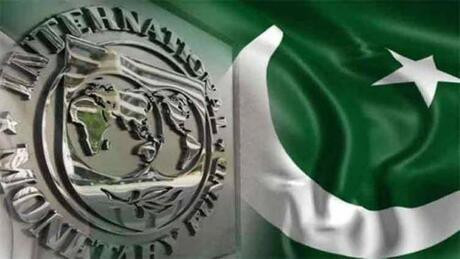

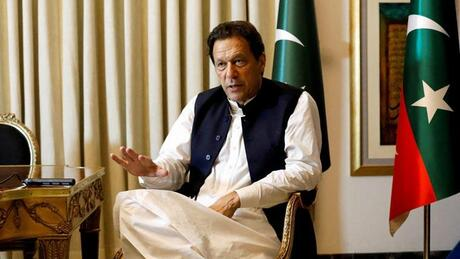

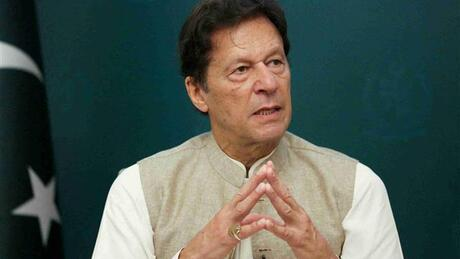

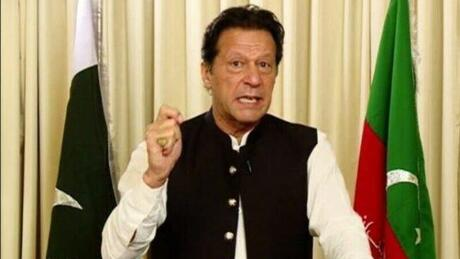

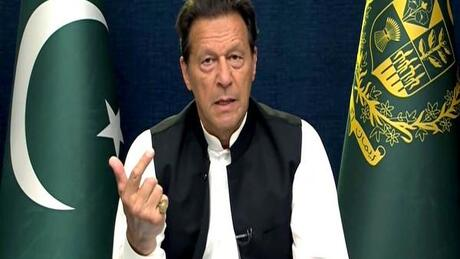

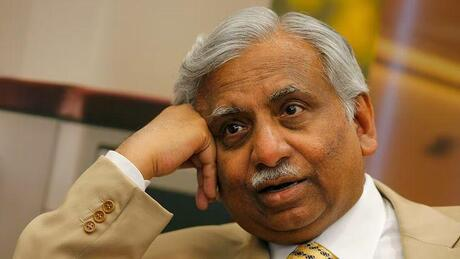

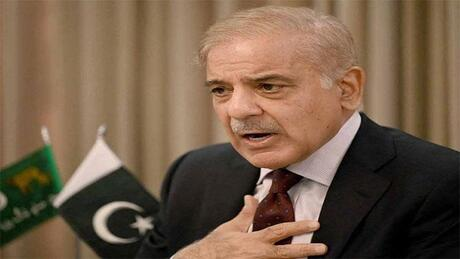

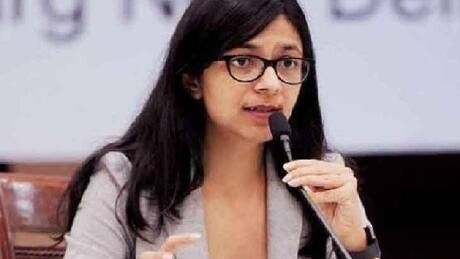

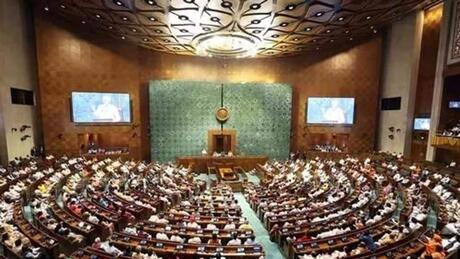

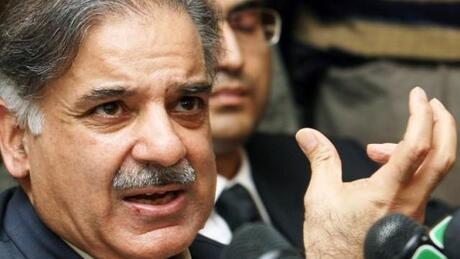

In [7]:
show_top_k_images(records,candidates_indices,10)

# Evaluation Dataset

In [8]:
def extract_queries(df, column="article_title"):
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found in DataFrame")

    queries = (
        df[column]
        .dropna()
        .astype(str)
        .str.strip()
    )

    queries = queries[queries.str.len() > 5]

    return queries.tolist()

def deduplicate_queries(queries):
    seen = set()
    unique = []

    for q in queries:
        q_norm = q.lower().strip()
        if q_norm not in seen:
            seen.add(q_norm)
            unique.append(q)

    return unique

def stratified_sample(queries, n=100, seed=42):
    random.seed(seed)

    short = [q for q in queries if len(q.split()) <= 5]
    medium = [q for q in queries if 5 < len(q.split()) <= 10]
    long = [q for q in queries if len(q.split()) > 10]

    def safe_sample(lst, k):
        return random.sample(lst, min(len(lst), k))

    sampled = []
    sampled += safe_sample(short, n // 3)
    sampled += safe_sample(medium, n // 3)
    sampled += safe_sample(long, n - len(sampled))

    remaining = list(set(queries) - set(sampled))
    if len(sampled) < n:
        sampled += random.sample(remaining, n - len(sampled))

    return sampled

def retrieve_top_k(query, k, records, image_embeddings, text_encoder):
    q_emb = text_encoder(query)  # shape (D,)
    q_emb = q_emb / np.linalg.norm(q_emb)
    img_embs = image_embeddings / np.linalg.norm(image_embeddings, axis=1, keepdims=True)
    scores = img_embs @ q_emb  # (N,)
    top_indices = np.argsort(scores)[::-1][:k]
    results = []
    for rank, idx in enumerate(top_indices, start=1):
        results.append({
            "rank": rank,
            "image_id": records[idx].get("image_id", idx),
            "image_path": records[idx]["image_path"],
            "title": records[idx].get("title", ""),
            "score": float(scores[idx])
        })
    return results

In [9]:
queries = extract_queries(dataset)
queries = deduplicate_queries(queries)
queries = stratified_sample(queries)
len(queries)

100

In [10]:
records

[{'image_path': '../dataset/newsimages_train_26_v1.1/news_images/2745A43B9E53413E39DFD0B2E52500B1.jpg',
  'title': 'Helena Agri-Enterprises hosts Evolve Innovations Expo in Memphis'},
 {'image_path': '../dataset/newsimages_train_26_v1.1/news_images/37FC359AB91C0DC6D21D270AED0C87E3.jpg',
  'title': 'No Evidence Of Toddler On Highway Before Carlee Russell Vanished: Cops'},
 {'image_path': '../dataset/newsimages_train_26_v1.1/news_images/59495628A854CBBC399881F38DF6471F.jpg',
  'title': 'Laramie Rangers Play Final Home Games of 2023'},
 {'image_path': '../dataset/newsimages_train_26_v1.1/news_images/74921B2C67ED9EA6A509A09FFE2C42DC.jpg',
  'title': "'Undesired' air brake release behind B.C. train derailment near Alberta: report"},
 {'image_path': '../dataset/newsimages_train_26_v1.1/news_images/E10A3861C9122D8704CFE5A6A8343867.jpg',
  'title': "Why England CAN win the Women's World Cup 2023 - despite missing key players"},
 {'image_path': '../dataset/newsimages_train_26_v1.1/news_images/9

In [11]:
eval_data = []
text_encoder = lambda q: encode_texts([q], model, device)[0]
for i, query in enumerate(queries):
    results = retrieve_top_k(query,10,records,image_embeddings,text_encoder)
    
    candidates = []
    for rank, r in enumerate(results, start=1):
        candidates.append({
            "rank": rank,
            "image_id": int(r["image_id"]),
            "image_path": r["image_path"],
            "title":r["title"],
            "score": float(r["score"]),
            "label": None
        })

    eval_data.append({
        "query_id": f"q_{i:03d}",
        "query_text": query,
        "candidates": candidates
    })

In [12]:
eval_data

[{'query_id': 'q_000',
  'query_text': 'Evangelical Methodists in church struggle',
  'candidates': [{'rank': 1,
    'image_id': 7008,
    'image_path': '../dataset/newsimages_train_26_v1.1/news_images/04FB061FCFE42DBB660E1F8F0CEAC4FF.jpg',
    'title': "Prairie St. John's launches new walk-in medication management program",
    'score': 0.29759249091148376,
    'label': None},
   {'rank': 2,
    'image_id': 5820,
    'image_path': '../dataset/newsimages_train_26_v1.1/news_images/5BF10F080C39F99BEA4C8A357253D911.jpg',
    'title': 'Texas atheist group sues Fort Worth after denied banner ads',
    'score': 0.295449823141098,
    'label': None},
   {'rank': 3,
    'image_id': 3323,
    'image_path': '../dataset/newsimages_train_26_v1.1/news_images/3E9F706DEF0E99C93BC66B60C213D7D1.jpg',
    'title': 'Sex Abuse Lawsuits Force Upstate NY Diocese To File For Bankruptcy',
    'score': 0.2853201627731323,
    'label': None},
   {'rank': 4,
    'image_id': 1438,
    'image_path': '../dataset/ne

In [13]:
import json

final_json = {
    "dataset_name": "news_image_eval_v1",
    "created_from": "clip_baseline_vitb16",
    "queries": eval_data
}

with open("../dataset/eval_dataset.json", "w") as f:
    json.dump(final_json, f, indent=2)

In [ ]:
!streamlit run ../app.py



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.1.34:8501

